In [2]:
# from the testing.csv, plot a bar chart showing the number of occurances of each patientID (given that we have from 001 to 369)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ks_2samp
import os
import seaborn as sns


In [21]:
"""
Glioblastoma csv structure: Patient,SliceIndex (patients have several slices. we choose one)
"""
train = pd.read_csv("training_set.csv")
val = pd.read_csv("validation_set.csv")
test = pd.read_csv("testing_set.csv")

print(f"Glioblastoma dataset sizes: Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

# show biggest, smallest, mean size of tumor in each set of both datasets
def prepare(dataset = "glio", mode = "train"):
    if dataset == "glio":
        if mode == "train":
            base_dir = "/Users/martina/code/4year/new/data/glio_data/training_set_npy"
            csv_path = "/Users/martina/code/4year/new/data/glio_data/training_set.csv"
        elif mode == "val":
            base_dir = "/Users/martina/code/4year/new/data/glio_data/validation_set_npy"
            csv_path = "/Users/martina/code/4year/new/data/glio_data/validation_set.csv"
        elif mode == "test":
            base_dir = "/Users/martina/code/4year/new/data/glio_data/testing_set_npy"
            csv_path = "/Users/martina/code/4year/new/data/glio_data/testing_set.csv"
        
        # Construct image and mask filenames
        df = pd.read_csv(csv_path)
        
        df["image_path"] = df.apply(
            lambda row: os.path.join(base_dir, f"{row['Patient']:03d}_{row['SliceIndex']}.npy"), axis=1
        )
        df["mask_path"] = df.apply(
            lambda row: os.path.join(base_dir, f"{row['Patient']:03d}_{row['SliceIndex']}_mask.npy"), axis=1
        )

    elif dataset == "polyp":
        if mode == "train":
            base_dir = "/Users/martina/code/4year/new/data/polyp_data/po_training_set_npy"
            csv_path = "/Users/martina/code/4year/new/data/polyp_data/po_training_set.csv"
        elif mode == "val":
            base_dir = "/Users/martina/code/4year/new/data/polyp_data/po_validation_set_npy"
            csv_path = "/Users/martina/code/4year/new/data/polyp_data/po_validation_set.csv"
        else:
            base_dir = "/Users/martina/code/4year/new/data/polyp_data/po_testing_set_npy"
            csv_path = "/Users/martina/code/4year/new/data/polyp_data/po_testing_set.csv"
        
        # Construct image and mask filenames
        df = pd.read_csv(csv_path)
        
        df["image_path"] = df.apply(
            lambda row: os.path.join(base_dir, f"{row['Patient']}.npy"), axis=1
        )
        df["mask_path"] = df.apply(
            lambda row: os.path.join(base_dir, f"{row['Patient']}_mask.npy"), axis=1
        )

    else:
        print("Dataset not recognized. Please choose 'glio' or 'polyp'.")
        
    # Sanity check (optional)
    pairs = [
        (img, mask)
        for img, mask in zip(df["image_path"], df["mask_path"])
        if os.path.exists(img) and os.path.exists(mask)
    ]
    return pairs

datasets = ["glio"]
modes = ["train", "val", "test"]
for dataset in datasets:
    for mode in modes:
        sizes = []
        for img_path, mask_path in prepare(dataset=dataset, mode=mode):
            mask = np.load(mask_path)
            tumor_size = np.sum(mask > 0)
            sizes.append(tumor_size)
        #use two decimal places
        print(f" {dataset.capitalize()} {mode.capitalize()} set - \n"
              f"     Min: {np.min(sizes):.2f} ({np.min(sizes)/mask.size*100:.2f}%), \n"
              f"     Max: {np.max(sizes):.2f} ({np.max(sizes)/mask.size*100:.2f}%), \n"
              f"     Mean: {np.mean(sizes):.2f} ({np.mean(sizes)/mask.size*100:.2f}%)")
        print(f"Standard Deviation: {np.std(sizes):.2f} ({np.std(sizes)/mask.size*100:.2f}%)")
        
    print("\n")

Glioblastoma dataset sizes: Train: 582, Val: 147, Test: 100
 Glio Train set - 
     Min: 161.00 (0.28%), 
     Max: 6167.00 (10.71%), 
     Mean: 2170.69 (3.77%)
Standard Deviation: 1114.47 (1.93%)
 Glio Val set - 
     Min: 353.00 (0.61%), 
     Max: 6379.00 (11.07%), 
     Mean: 2062.35 (3.58%)
Standard Deviation: 1140.21 (1.98%)
 Glio Test set - 
     Min: 296.00 (0.51%), 
     Max: 4910.00 (8.52%), 
     Mean: 1872.80 (3.25%)
Standard Deviation: 999.33 (1.73%)




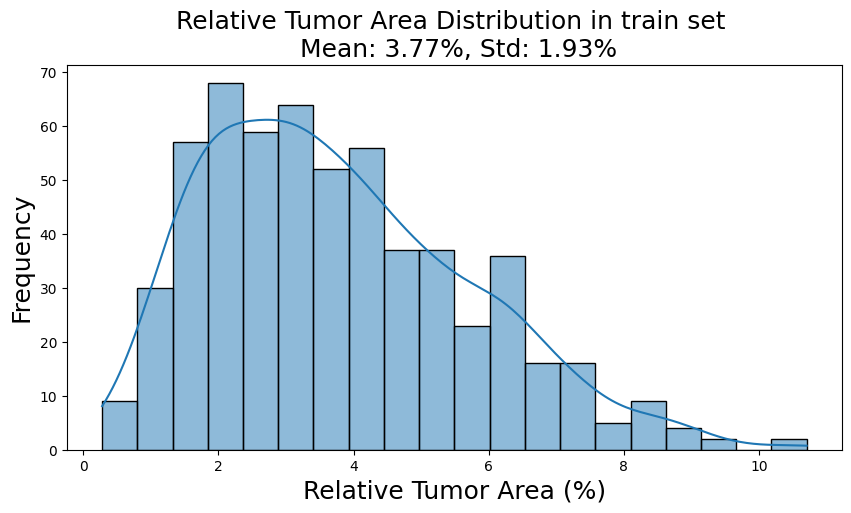

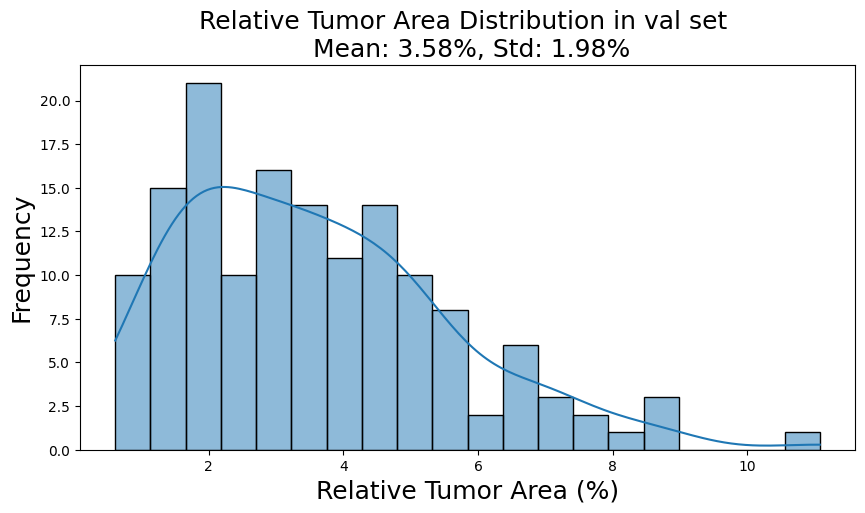

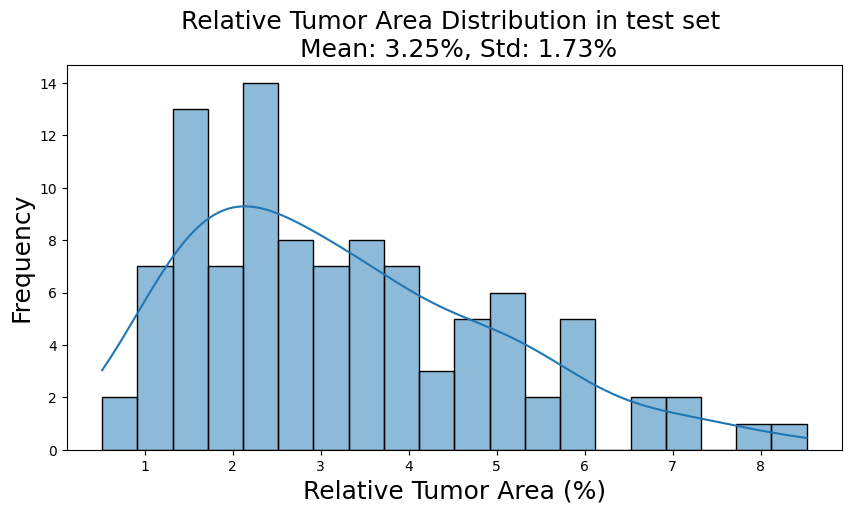

In [41]:
# mark in read the mean and display standard deviation
path = "/Users/martina/code/4year/new/data/glio_data"
modes = ["train", "val", "test"]
for mode in modes:
    # plot relative area of tumor in each datapoint in the mode
    areas = []
    if mode == "train":
        df = train
        path_next = os.path.join(path, "training_set_npy")
    elif mode == "val":
        df = val
        path_next = os.path.join(path, "validation_set_npy")
    else:
        df = test
        path_next = os.path.join(path, "testing_set_npy")
    for index, row in df.iterrows():
        # if row["Patient"] is 35, patient is 035
        patient = f"{int(row['Patient']):03d}"
        slice_index = row["SliceIndex"]
        mask_path = os.path.join(path_next, f"{patient}_{slice_index}_mask.npy")
        mask = np.load(mask_path)
        area = np.sum(mask > 0) / mask.size * 100  # relative area in percentage
        areas.append(area)
    
    mean_area = np.mean(areas)
    std_area = np.std(areas)
    
    plt.figure(figsize=(10, 5))
    sns.histplot(areas, bins=20, kde=True)
    plt.title(f"Relative Tumor Area Distribution in {mode} set \n Mean: {mean_area:.2f}%, Std: {std_area:.2f}%", fontsize=18)
    plt.xlabel("Relative Tumor Area (%)", fontsize=18)
    plt.ylabel("Frequency", fontsize=18)
    plt.show()


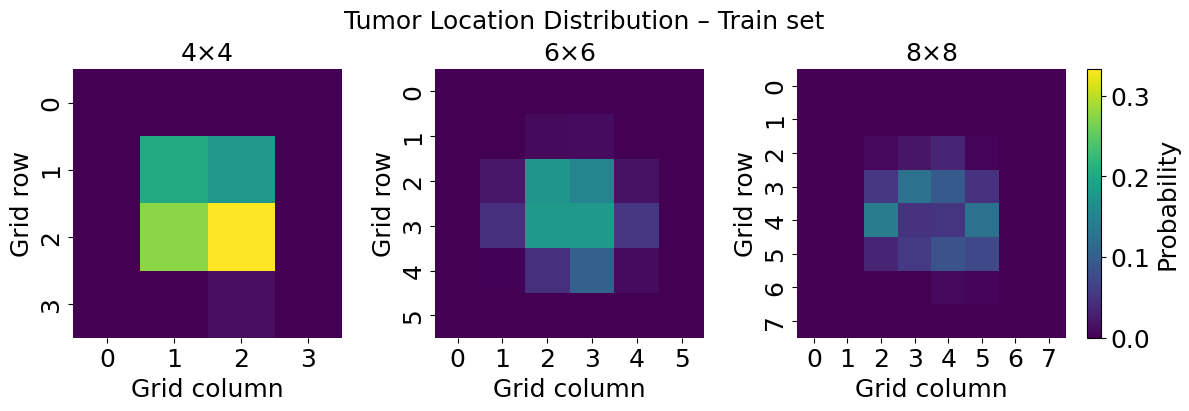

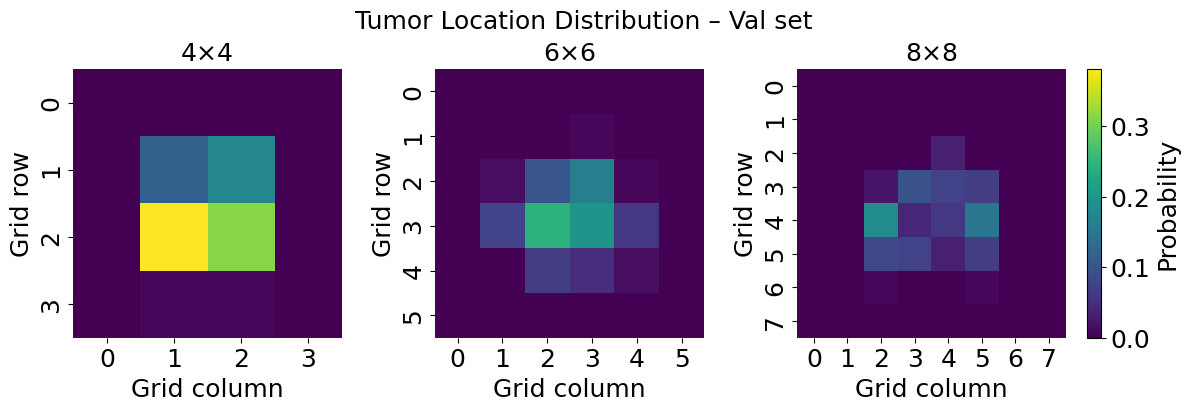

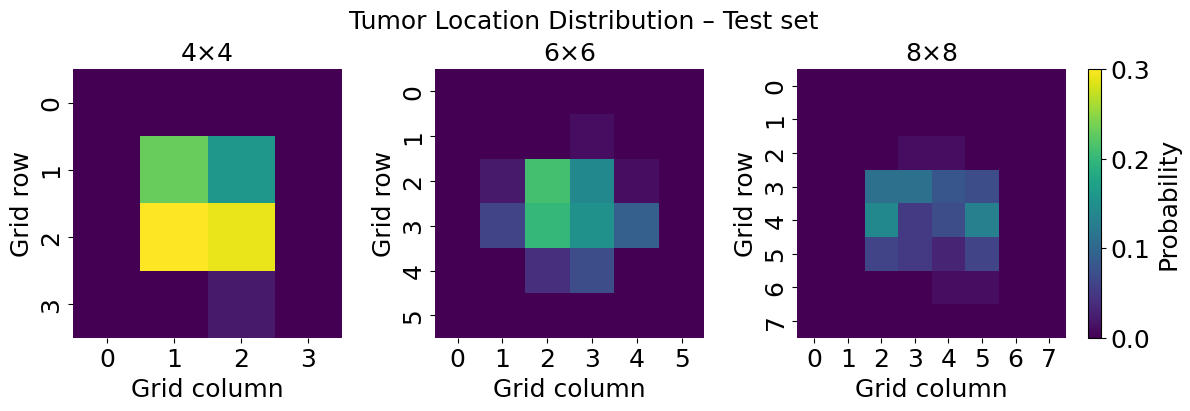

In [40]:
# This gives you a continuous (x, y) in image coordinates.
def tumor_centroid(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return xs.mean(), ys.mean()

# This is grid-agnostic and works for 4×4, 6×6, 8×8.
def centroid_to_cell(cx, cy, H, W, grid_size):
    cell_x = int(cx / W * grid_size)
    cell_y = int(cy / H * grid_size)
    return min(cell_y, grid_size-1), min(cell_x, grid_size-1)

# accumulate location histograms (gives normalized probability heatmap)
def tumor_location_heatmap(pairs, grid_size):
    heatmap = np.zeros((grid_size, grid_size))

    for _, mask_path in pairs:
        mask = np.load(mask_path)
        centroid = tumor_centroid(mask)
        if centroid is None:
            continue

        H, W = mask.shape
        r, c = centroid_to_cell(*centroid, H, W, grid_size)
        heatmap[r, c] += 1

    return heatmap / heatmap.sum()

def plot_location_heatmaps_for_mode(pairs, mode, grid_sizes=[4, 6, 8]):
    heatmaps = {g: tumor_location_heatmap(pairs, g) for g in grid_sizes}
    vmax = max(hm.max() for hm in heatmaps.values())

    fig, axes = plt.subplots(
        1, len(grid_sizes),
        figsize=(4 * len(grid_sizes), 4),
        constrained_layout=True
    )
    if len(grid_sizes) == 1:
        axes = [axes]

    mappable = None  # <-- IMPORTANT

    for ax, g in zip(axes, grid_sizes):
        hm_plot = sns.heatmap(
            heatmaps[g],
            ax=ax,
            cmap="viridis",
            square=True,
            cbar=False,      # disable individual colorbars
            annot=False,
            vmin=0,
            vmax=vmax
        )

        # Save ONE mappable (first one is enough)
        if mappable is None:
            mappable = hm_plot.collections[0]

        ax.set_title(f"{g}×{g}", fontsize=18)
        ax.set_xlabel("Grid column", fontsize=18)
        ax.set_ylabel("Grid row", fontsize=18)
        ax.tick_params(axis='both', labelsize=18)

    # ONE shared colorbar
    cbar = fig.colorbar(
        mappable,
        ax=axes,
        orientation="vertical",
        fraction=0.04,
        pad=0.02
    )
    cbar.set_label("Probability", fontsize=18)
    cbar.ax.tick_params(labelsize=18)

    fig.suptitle(f"Tumor Location Distribution – {mode.capitalize()} set", fontsize=18)
    # plt.tight_layout()
    plt.show()



for mode in modes:
    pairs = prepare(dataset="glio", mode=mode)
    plot_location_heatmaps_for_mode(pairs, mode, grid_sizes=[4, 6, 8])


